# PDA-1. Предобработка текстов с помощью Python

## 1. Введение. Задачи на текстах

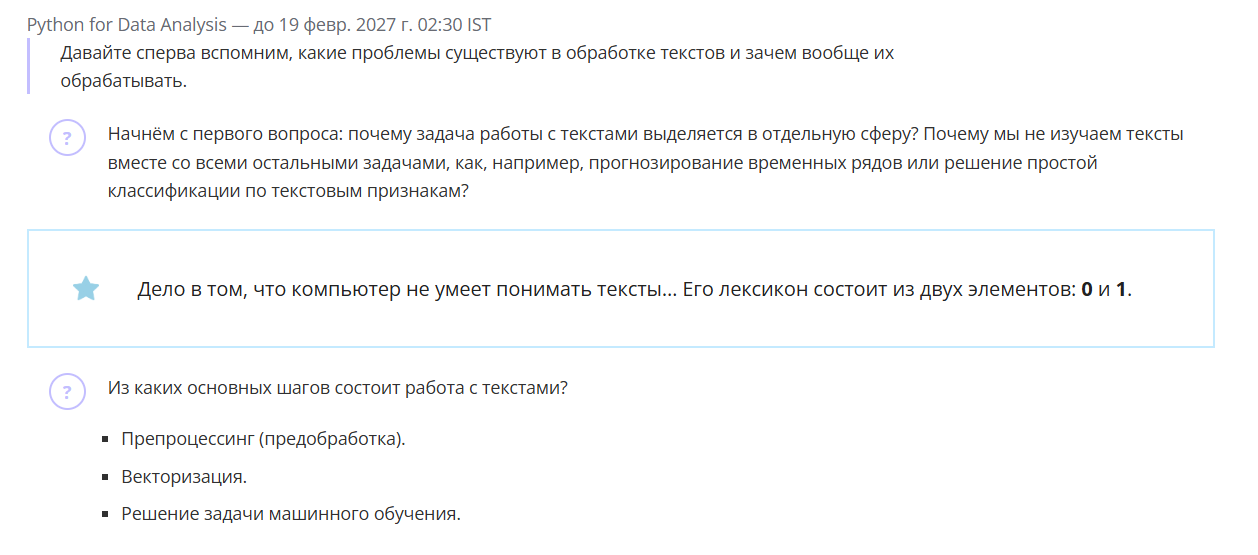

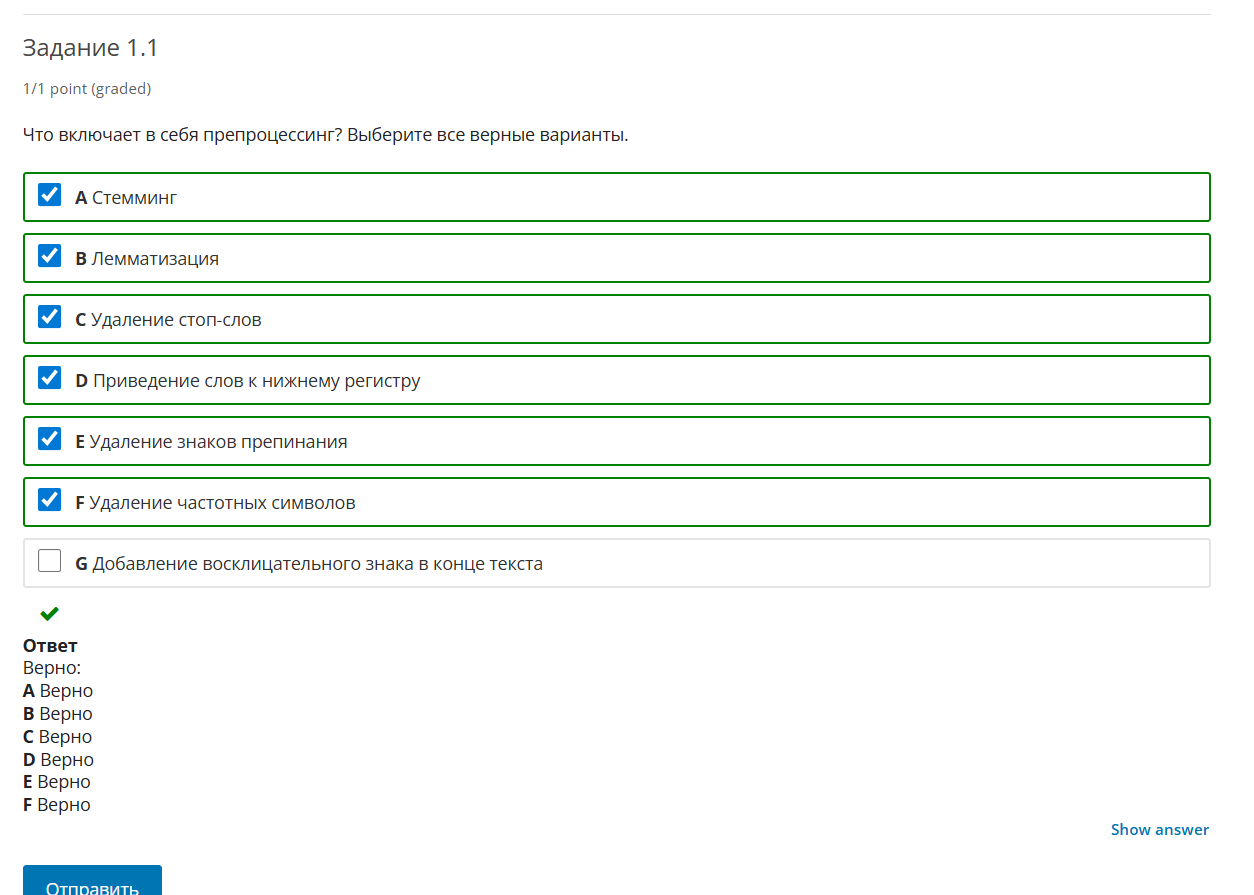

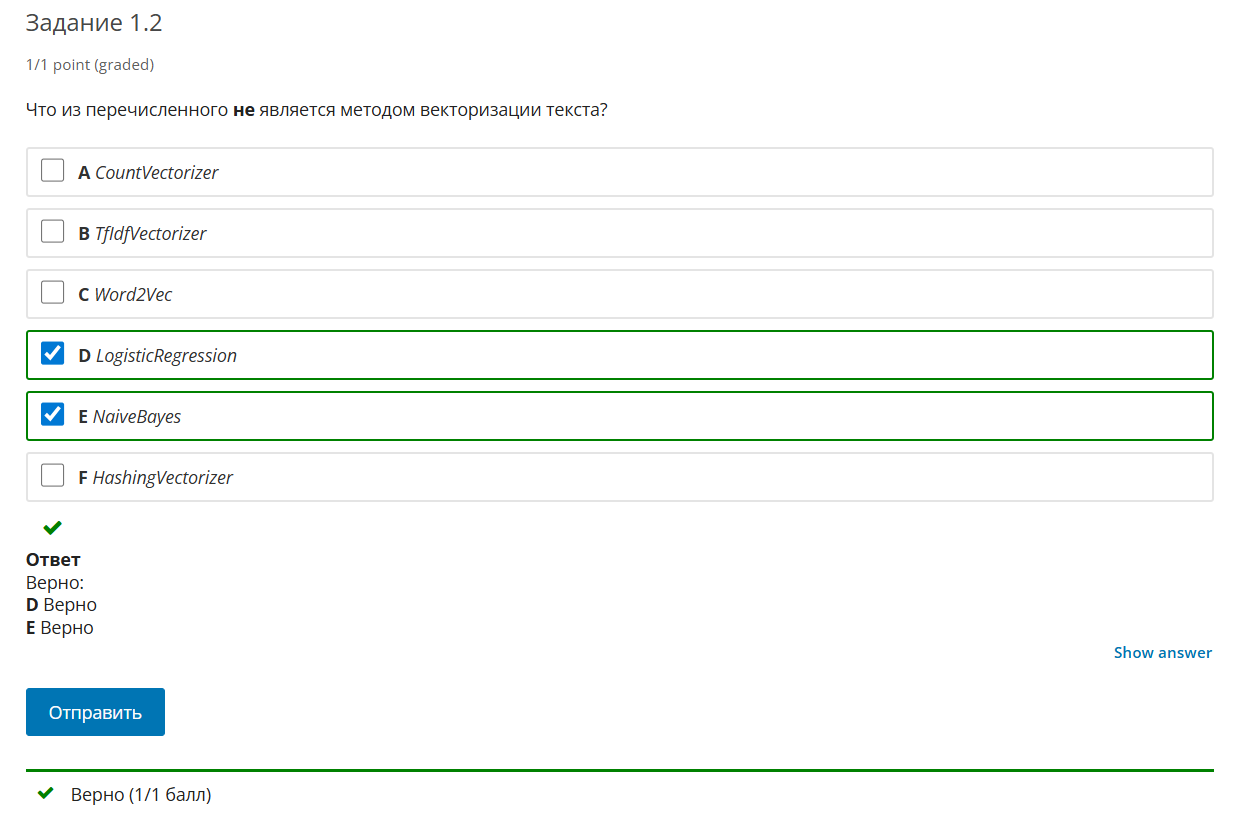

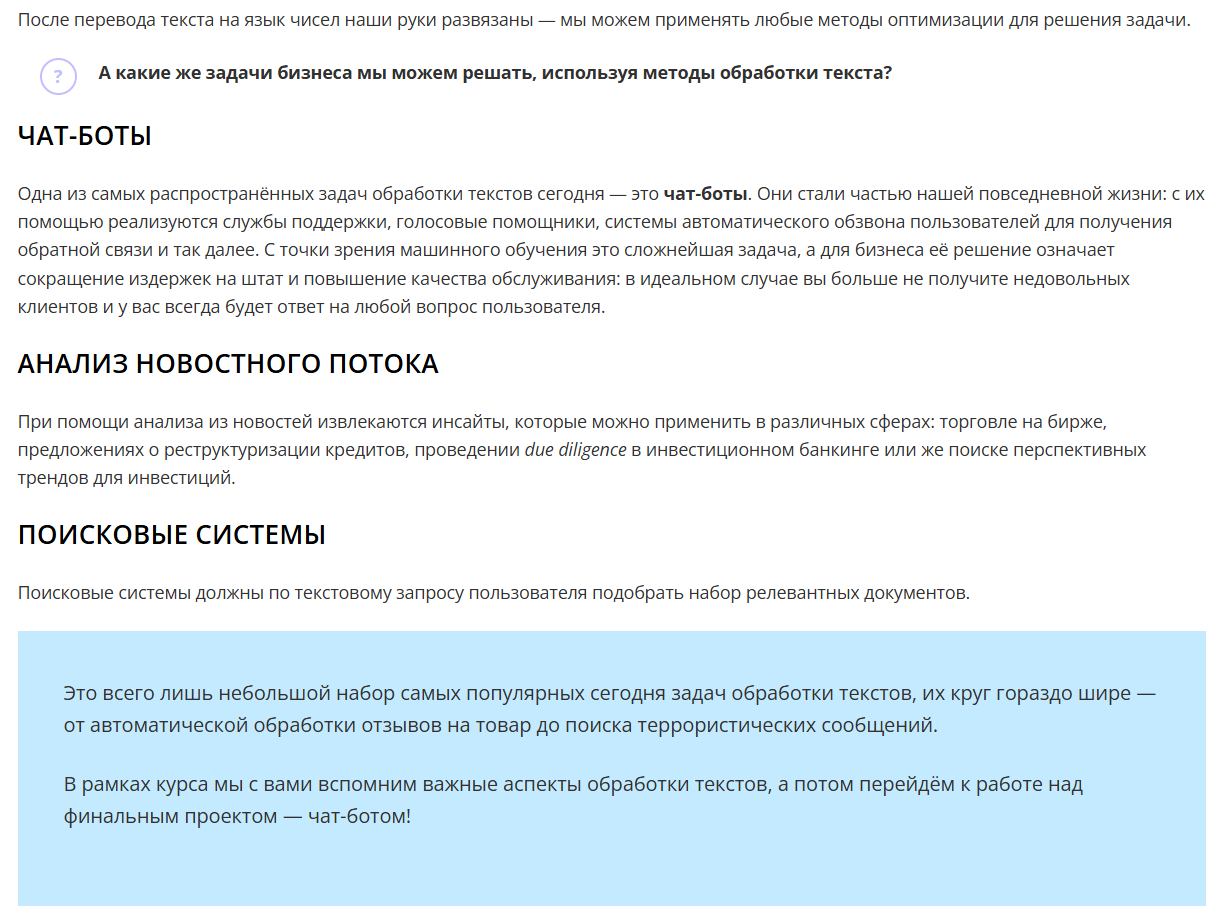

# 2. Проект этого модуля

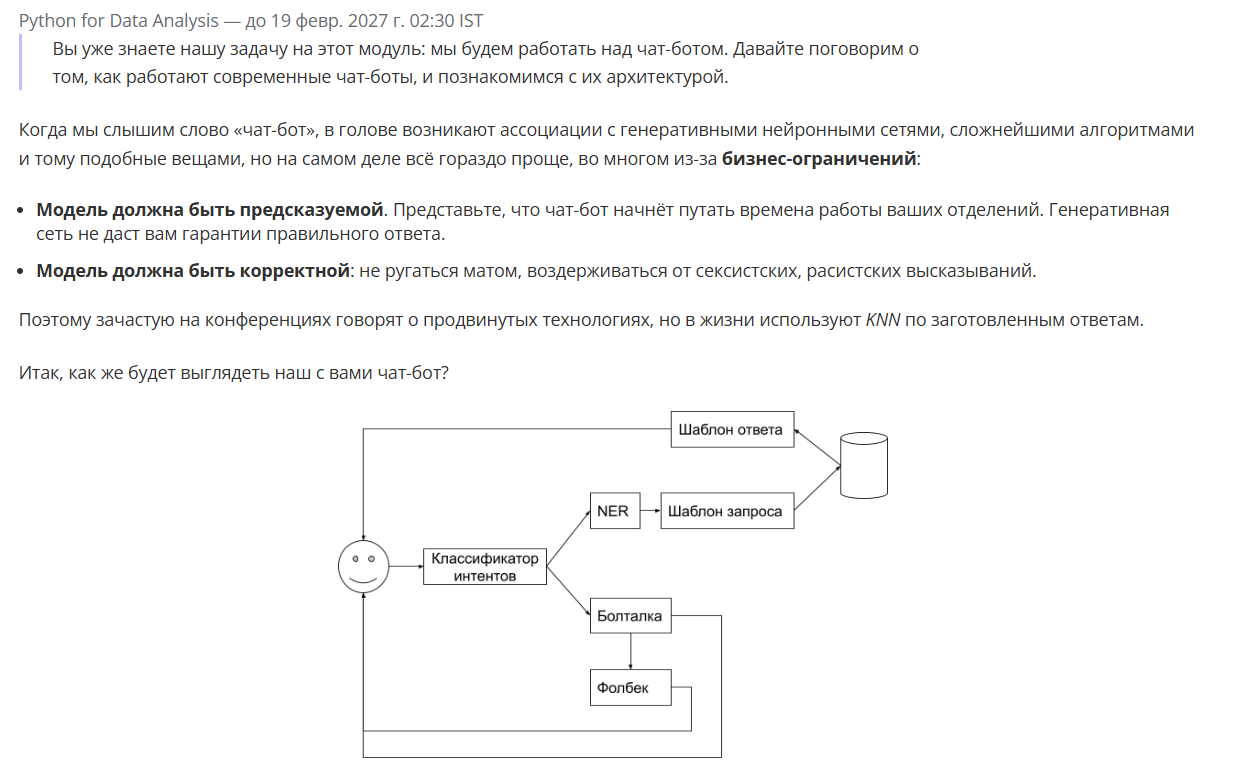

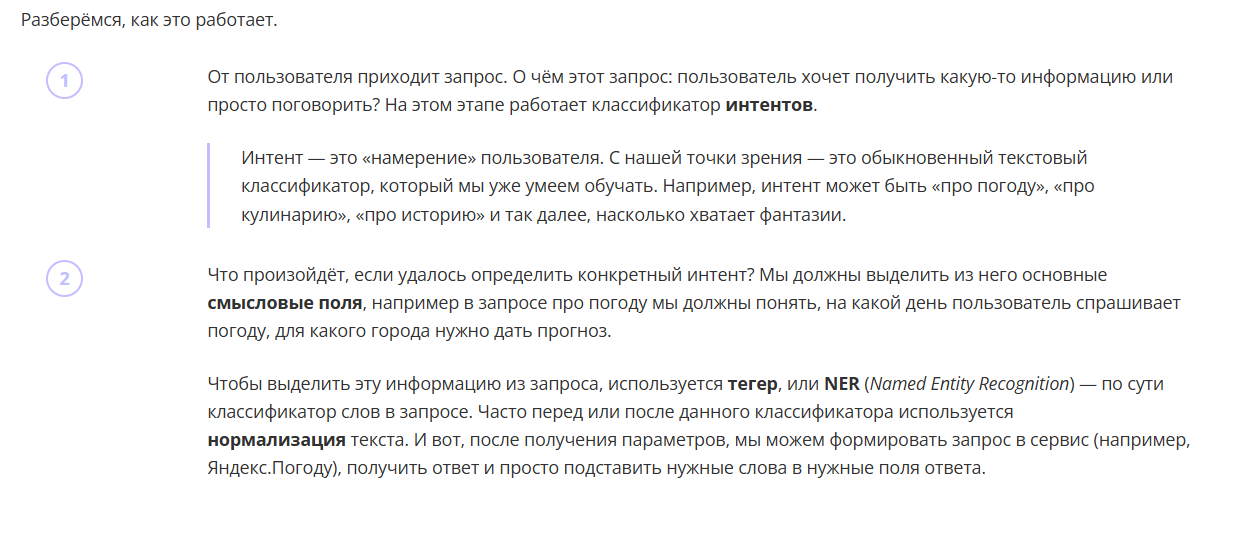

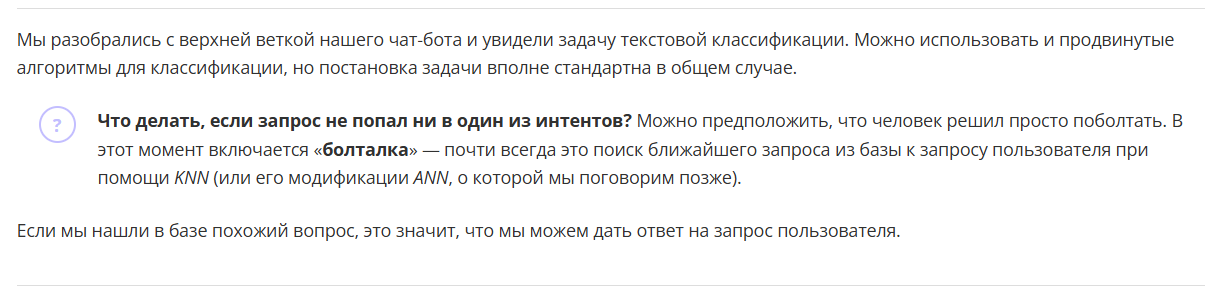

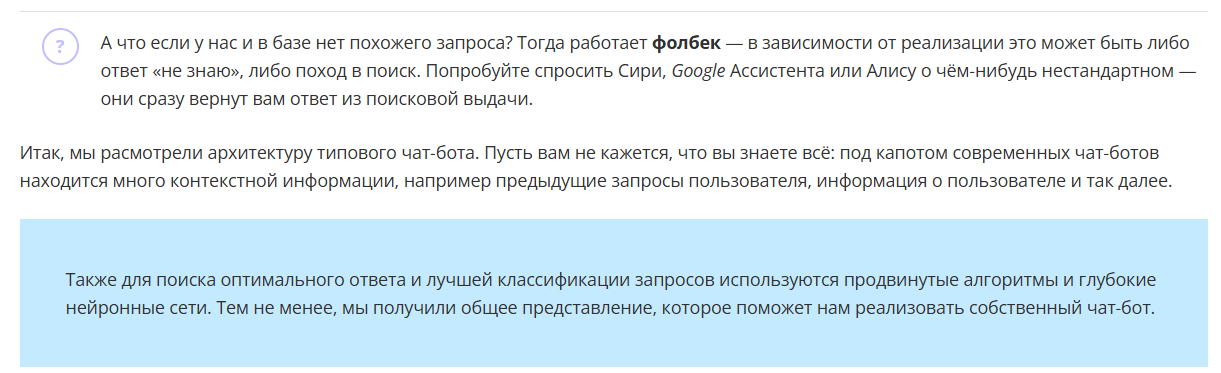

# 3. Предобработка текстовых данных: стемминг, лемматизация

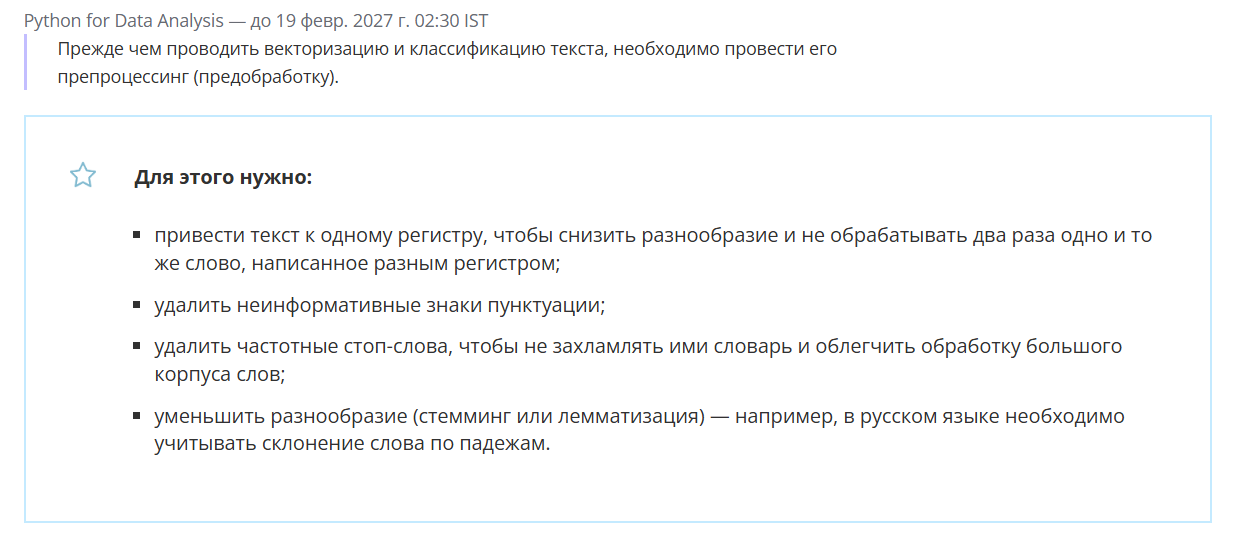

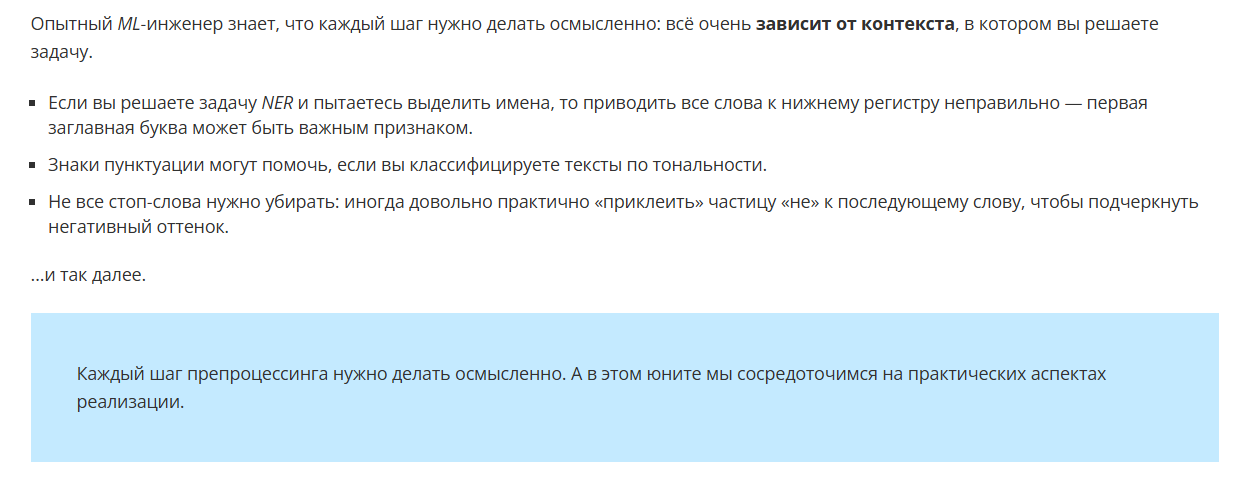

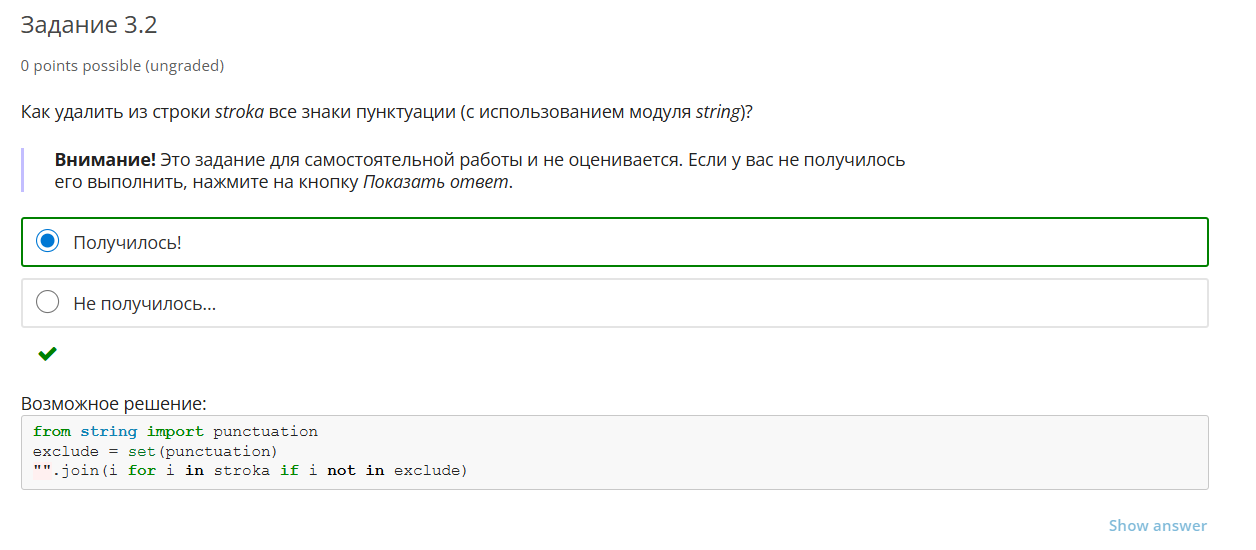

In [ ]:
from string import punctuation
exclude = set(punctuation)
"".join(i for i in stroka if i not in exclude)

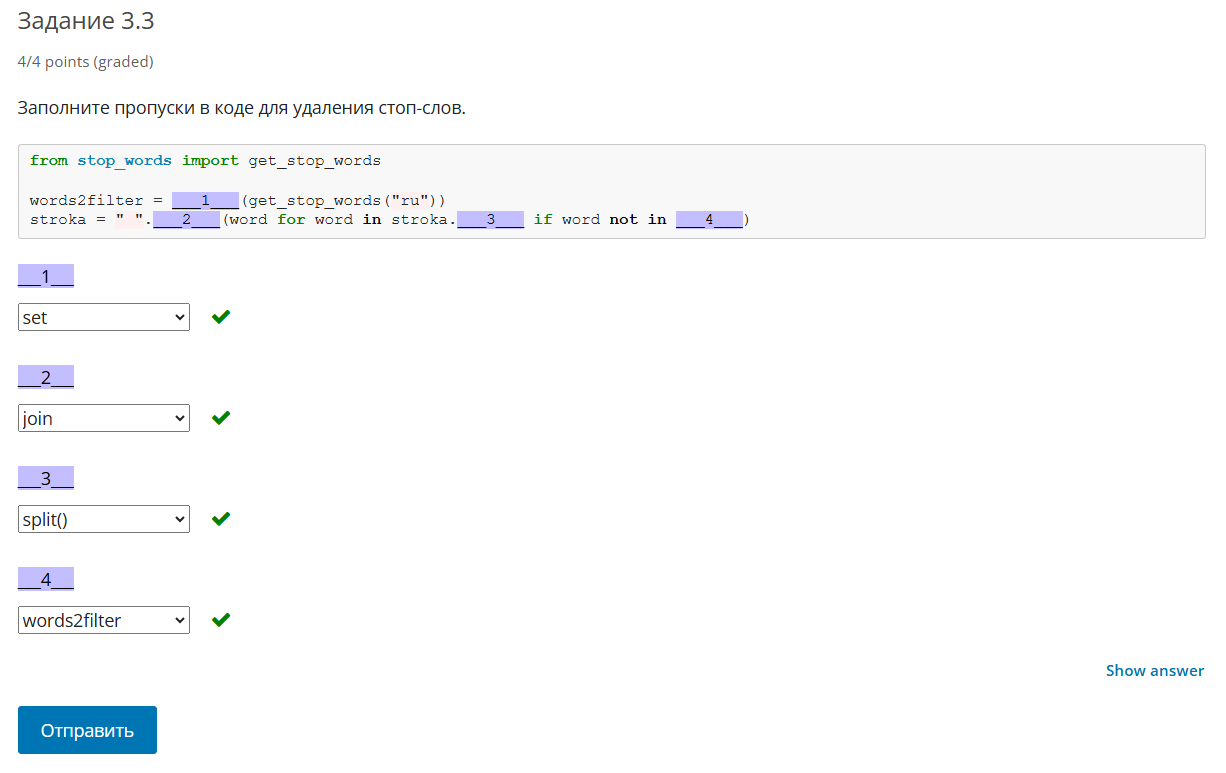

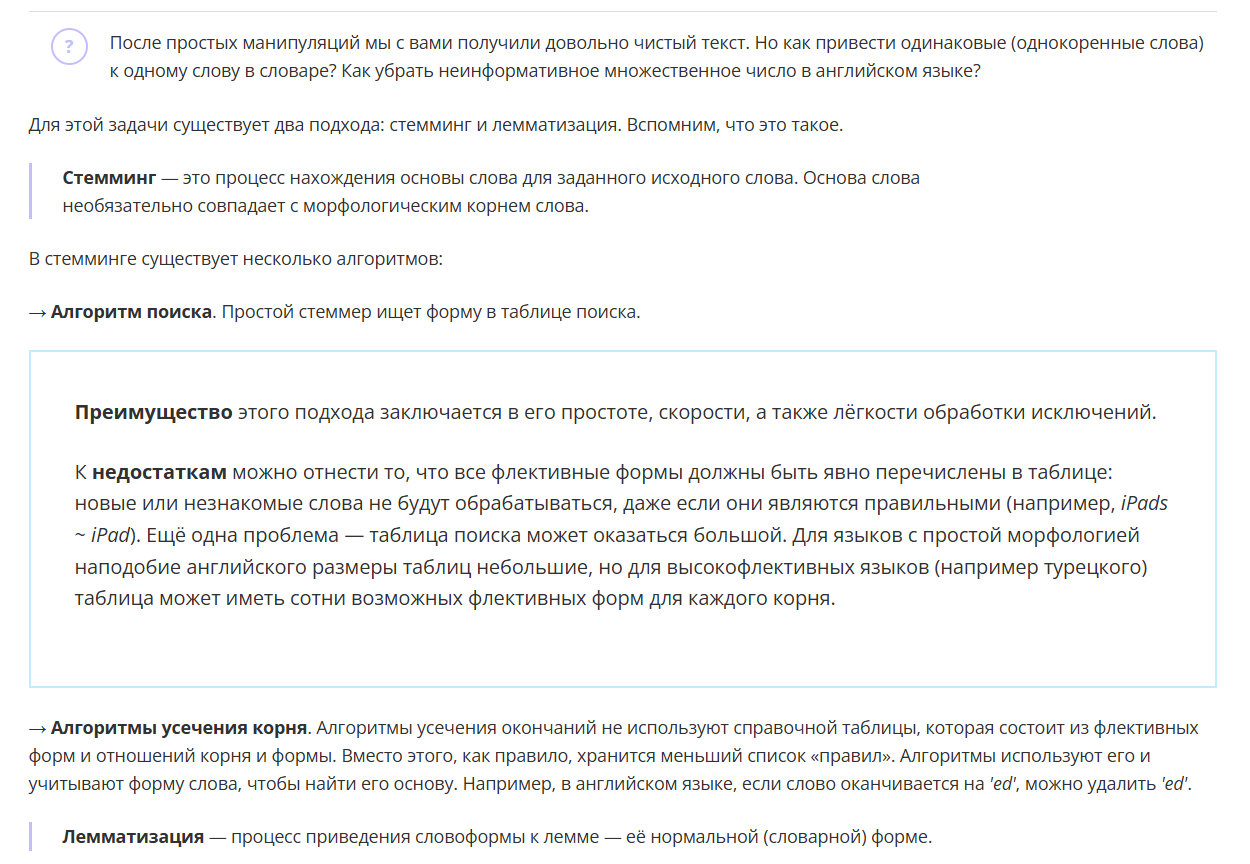

Стемминг — это процесс нахождения основы слова для заданного исходного слова. Основа слова необязательно совпадает с морфологическим корнем слова. 

Лемматизация — процесс приведения словоформы к лемме — её нормальной (словарной) форме.

Скринкаст: предобработка текста

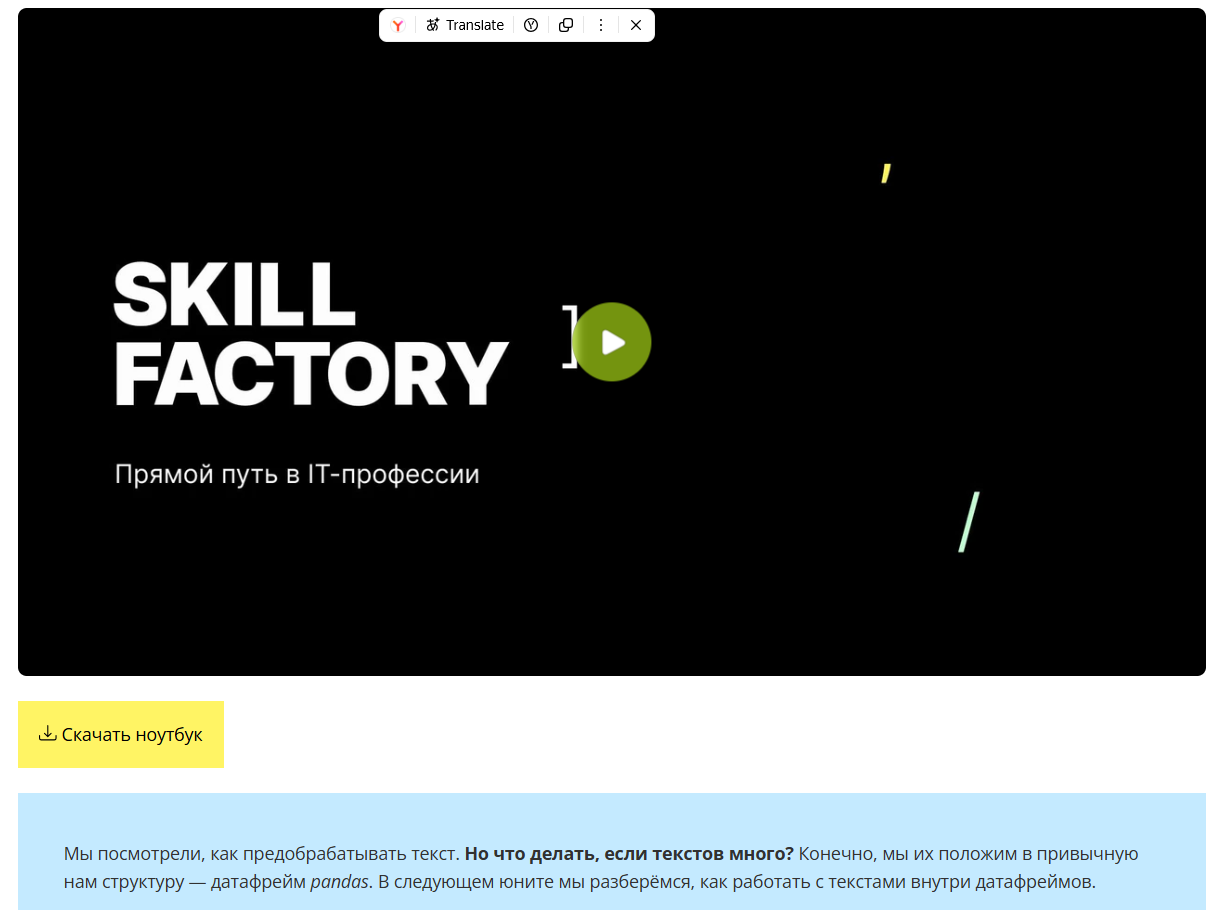

# 4. Предобработка текстовых данных внутри pandas-датафрейма

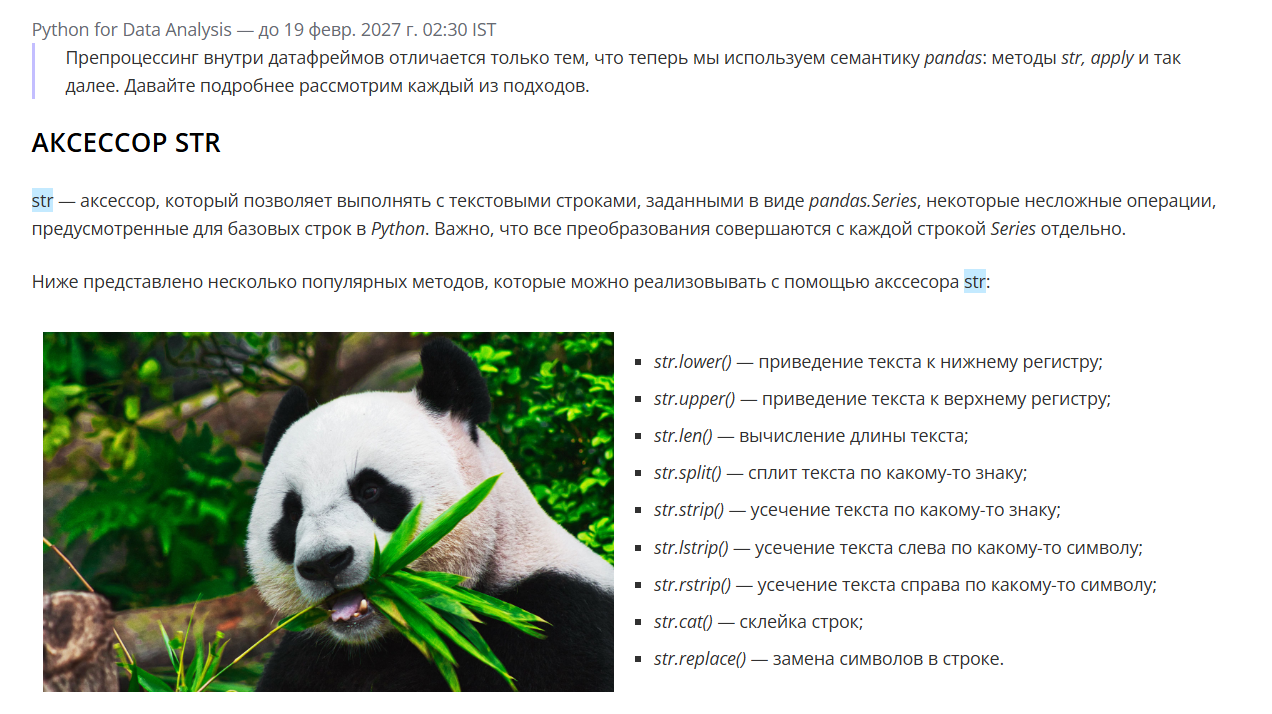

Все методы перечислены здесь. https://pandas.pydata.org/pandas-docs/stable/user_guide/text.html

Общий синтаксис применения преобразований будет выглядеть следующим образом:

Series.str.<имя_метода>

Давайте посмотрим простой пример использования аксессора str. Предположим, у нас есть некоторая pandas.Series:

In [1]:
import pandas as pd

s = pd.Series(
    ["Разруха не в клозетах, а в головах. ",
     "Люди как люди. Любят деньги, но ведь это всегда было.",
     "Там хорошо, где нас нет: в прошлом нас уже нет, и оно кажется прекрасным.",
     "Нет силы более могучей, чем знание; человек, вооружённый знанием, — непобедим."
     ],
    dtype="string"
)

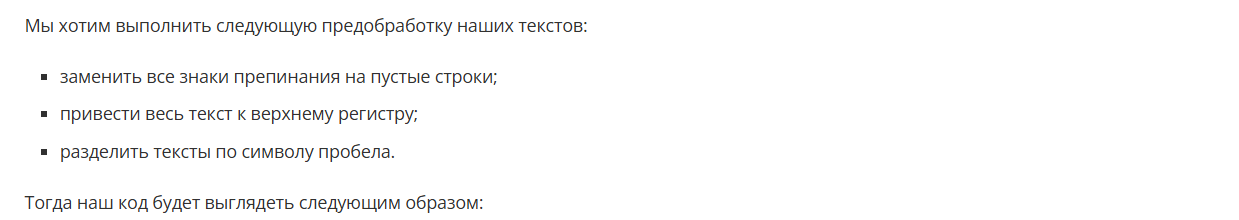

In [2]:
import string

# Создаем множество из символов пунктуации
exclude = set(string.punctuation)

# Заменяем символы пунктуации на пустые строки
s = s.str.replace(f'[{string.punctuation}]', '', regex=True)
# Приводим тексты к нижнему регистру
s = s.str.upper()
# Разделяем тексты по пробелу
s = s.str.split(' ')
print(s)

0          [РАЗРУХА, НЕ, В, КЛОЗЕТАХ, А, В, ГОЛОВАХ, ]
1    [ЛЮДИ, КАК, ЛЮДИ, ЛЮБЯТ, ДЕНЬГИ, НО, ВЕДЬ, ЭТО...
2    [ТАМ, ХОРОШО, ГДЕ, НАС, НЕТ, В, ПРОШЛОМ, НАС, ...
3    [НЕТ, СИЛЫ, БОЛЕЕ, МОГУЧЕЙ, ЧЕМ, ЗНАНИЕ, ЧЕЛОВ...
dtype: object


А теперь давайте потренируемся!

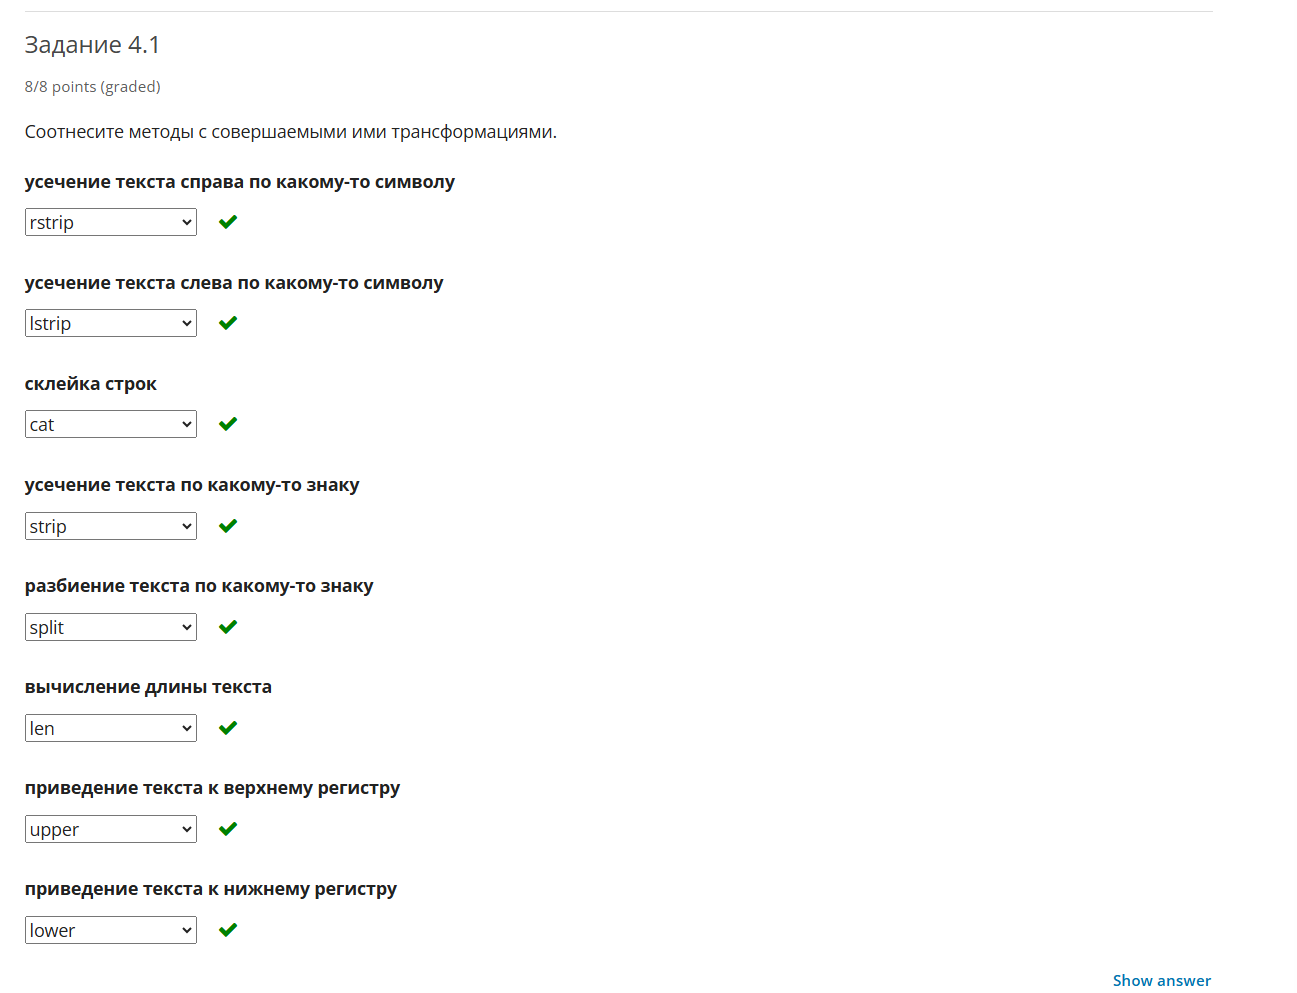

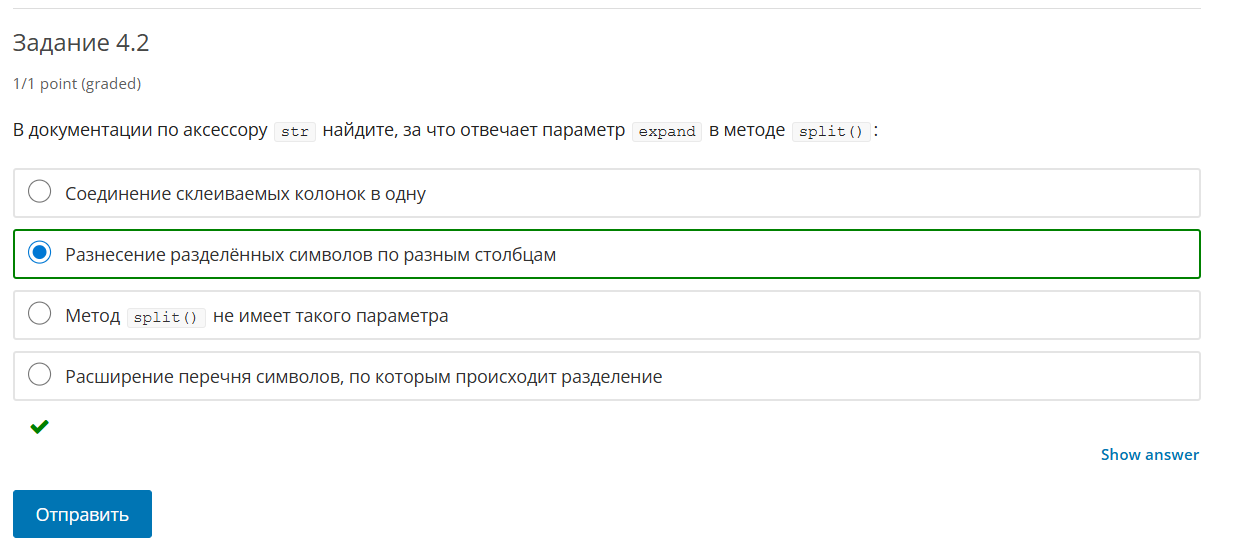

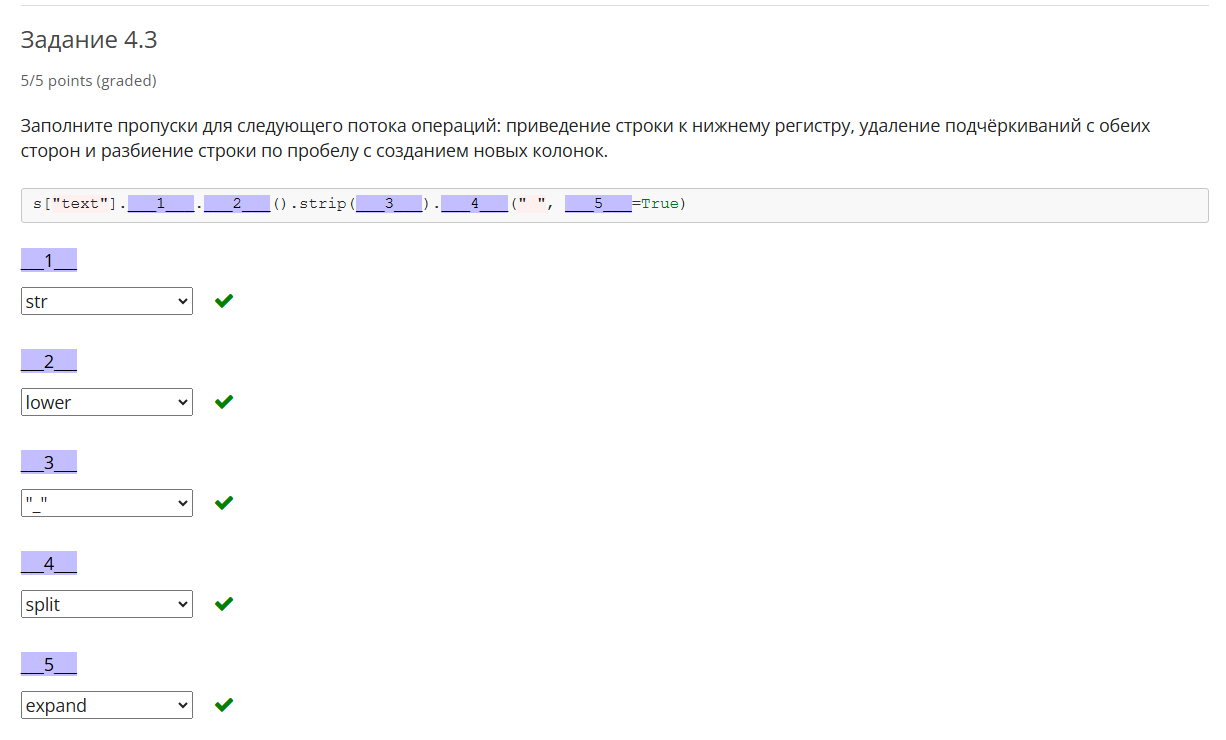

### Задание 4.4 (External resource)

Вам задана pandas.Series, ссылка на которую содержится в переменной s. Каждый элемент Series является текстом.

Пример переменной s:

In [ ]:
s = pd.Series(
    ["Авторитет и дружба вода и огонь, вещи разнородные и враждебные; равенство условие дружбы.",
     "Нет силы более могучей, чем знание; человек, вооружённый знанием, — непобедим.",
     "Истинная сила человека не в порывах, а в нерушимом спокойствии.",
     "Величайшее богатство народа его язык."
     ],
    dtype="string"
)

Вам необходимо произвести следующие операции:

- удалить все символы пунктуации из текстов;
- привести каждый из текстов к нижнему регистру;
- убрать лишние пробелы с обеих сторон текстов;
- разбить тексты по пробелу на слова.
- В результате работы программы у вас должна получиться новая Series с именем new_s, которая состоит из списков слов.

Пример работы программы:

In [ ]:
s = pd.Series([
     "Авторитет и дружба вода и огонь, вещи разнородные и враждебные; равенство условие дружбы.",
     "Нет силы более могучей, чем знание; человек, вооружённый знанием, непобедим.",
     "Истинная сила человека не в порывах, а в нерушимом спокойствии.",
     "Величайшее богатство народа его язык."
     ],
    dtype="string"
)

# Код преобразования

print(new_s)

"""
0    [авторитет, и, дружба, вода, и, огонь, вещи, р...
1    [нет, силы, более, могучей, чем, знание, челов...
2    [истинная, сила, человека, не, в, порывах, а, ...
3           [величайшее, богатство, народа, его, язык]
dtype: object
"""


Примечание №1: Обратите внимание, что для отправки кода на проверку переменную s объявлять не нужно. Не забудьте удалить строку кода с её объявлением перед тем, как отправить код на тестирование.

Примечание №2: Важно, что при отправке на проверку программа не должна ничего выводить на экран! Удалите или закомментируйте вызовы функции print(), чтобы не нарушить работу проверочных тестов.

In [ ]:
import re

new_s = (
    s.str.replace(r"[^\w\s]", "", regex=True)  # удаляем пунктуацию
     .str.lower()                              # нижний регистр
     .str.strip()                              # убираем пробелы по краям
     .str.split()                              # разбиваем на слова
)

### ПРЕОБРАЗОВАНИЕ С ПОМОЩЬЮ APPLY

Конечно, мы можем использовать и метод apply() с вызовом какого-то метода. Предположим, у нас есть функция, которая выполняет предобработку текста:

In [3]:
import pandas as pd
import string
import pymorphy2
from nltk.corpus import stopwords

morpher = pymorphy2.MorphAnalyzer()

stop_words = set(stopwords.words('russian'))
sw = set(stop_words)

def preprocess_txt(line):
    # Почистим строку от пунктуации. Для этого пробежимся по каждому символу и проверим, не является ли он знаком пунктуации
    exclude = set(string.punctuation)
    spls = "".join(i for i in line.strip() if i not in exclude).split()
    # Лемматизируем все слова в нашем тексте
    spls = [morpher.parse(i.lower())[0].normal_form for i in spls]
    spls = [i for i in spls if i not in sw and i != ""]
    return spls

Применим эту функцию к созданной ранее Series:

In [4]:
s = pd.Series(
    ["Разруха не в клозетах, а в головах. ",
     "Люди как люди. Любят деньги, но ведь это всегда было.",
     "Там хорошо, где нас нет: в прошлом нас уже нет, и оно кажется прекрасным.",
     "Нет силы более могучей, чем знание; человек, вооружённый знанием, — непобедим."
     ],
    dtype="string"
)

# Применяем функцию для предобработки к Series
s = s.apply(lambda x: preprocess_txt(x))
print(s)

0                            [разруха, клозет, голова]
1              [человек, человек, любить, деньга, это]
2                 [прошлый, оно, казаться, прекрасный]
3    [сила, могучий, знание, человек, вооружённый, ...
dtype: object


Таким образом, мы используем метод apply(), который применяет заданную функцию препроцессинга к каждому значению колонки, создавая новый предобработанный столбец с текстами.

Это всё, что вам нужно знать о работе с текстами в Pandas.

А теперь давайте немного попрактикуемся!

### Задание 4.5 (External resource)

Пусть у нас есть некоторый pandas.DataFrame data, в котором представлены некоторые цитаты русских писателей и публицистов, со следующими столбцами в нем:

- label — имя автора;
- text — текст цитаты.

Мы хотим преобразовать цитаты. Для этого реализуйте функцию preprocess_txt(), которая принимает на вход строку и выполняет с ней следующие операции:

- удаляет все символы пунктуации из текстов;
- приводит все символы к нижнему регистру;
- инвертирует порядок слов (считаем, что слова разделены одиночными пробелами).

Пример работы функции:

In [ ]:
line = "Авторитет и дружба вода и огонь, вещи разнородные и враждебные; равенство условие дружбы."
print(preprocess_txt(line))
# ['дружбы', 'условие', 'равенство', 'враждебные', 'и', 'разнородные', 'вещи', 'огонь', 'и', 'вода', 'дружба', 'и', 'авторитет']


С помощью функции preprocess_txt() преобразуйте столбец text в заданном pandas.DataFrame data.

Пример работы программы:

In [ ]:
data = pd.DataFrame({
    'label': [
        'В. Белинский',
        'М. Горький',
        'Л. Толстой',
        'М. Шолохов'
        ],
    'text': [
        "Авторитет и дружба вода и огонь, вещи разнородные и враждебные; равенство условие дружбы.",
        "Нет силы более могучей, чем знание; человек, вооружённый знанием, непобедим.",
        "Истинная сила человека не в порывах, а в нерушимом спокойствии.",
        "Величайшее богатство народа его язык."
     ]
})

# Код преобразования

print(data)

"""
         label                                               text
0  В. Белинский  [дружбы, условие, равенство, враждебные, и, ра...
1    М. Горький  [непобедим, знанием, вооружённый, человек, зна...
2    Л. Толстой  [спокойствии, нерушимом, в, а, порывах, в, не,...
3    М. Шолохов         [язык, его, народа, богатство, величайшее]
"""


Примечание №1: Обратите внимание, что для отправки кода на проверку переменную data объявлять не нужно. Не забудьте удалить строку кода с ее объявлением перед тем как отправить код на тестирование.

Примечание №2: Важно, что при отправке на проверку программа не должна ничего выводить на экран! Удалите или закомментируйте вызовы функции print(), чтобы не нарушить работу проверочных тестов.

In [ ]:
import re

def preprocess_txt(line):
    line = re.sub(r"[^\w\s]", "", line)  # удаляем пунктуацию
    line = line.lower()                  # нижний регистр
    words = line.split(" ")              # разбиваем на слова
    return words[::-1]                   # инвертируем порядок слов

data["text"] = data["text"].apply(preprocess_txt)

# 5. Векторизация текстов

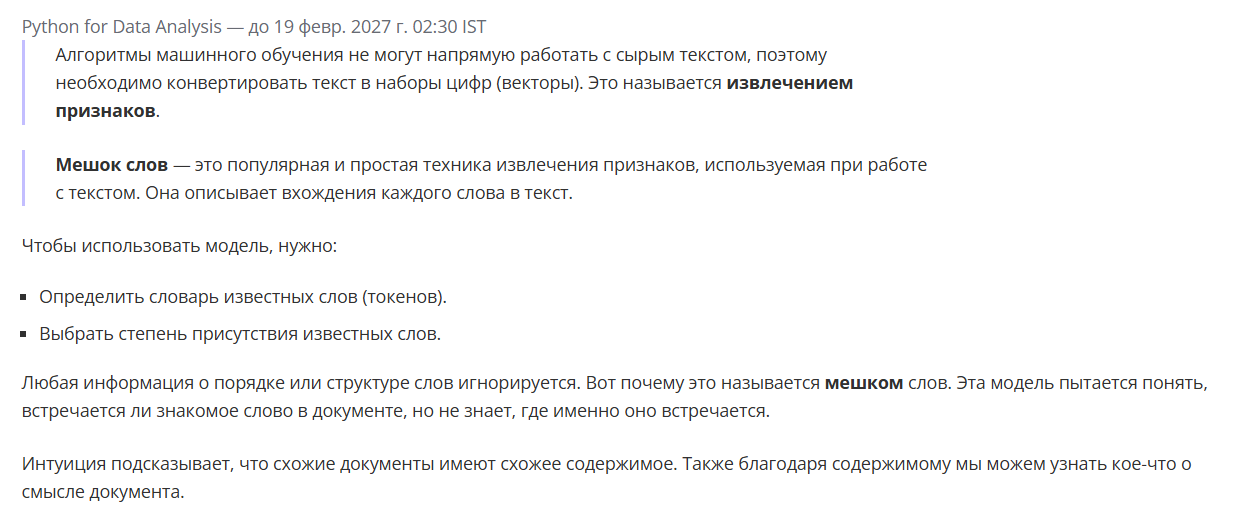

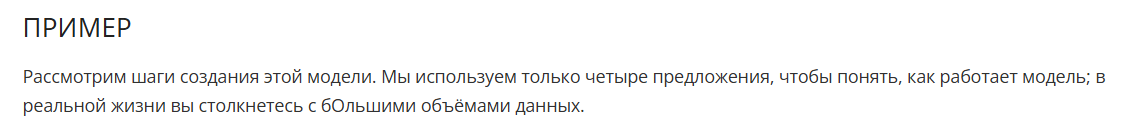

In [6]:
documents = ["I like this movie, it's funny.", 'I hate this movie.', 'This was awesome! I like it.', 'Nice one. I love it.']

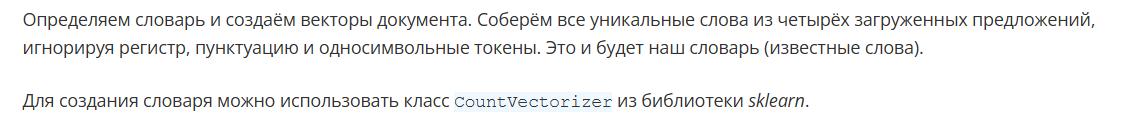

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

count_vectorizer = CountVectorizer()

# Создаем the Bag-of-Words модель
bag_of_words = count_vectorizer.fit_transform(documents)

# Отобразим Bag-of-Words модель как DataFrame
feature_names = count_vectorizer.get_feature_names_out()
pd.DataFrame(bag_of_words.toarray(), columns = feature_names)

,awesome,funny,hate,it,like,love,movie,nice,one,this,was
0,0,1,0,1,1,0,1,0,0,1,0
1,0,0,1,0,0,0,1,0,0,1,0
2,1,0,0,1,1,0,0,0,0,1,1
3,0,0,0,1,0,1,0,1,1,0,0


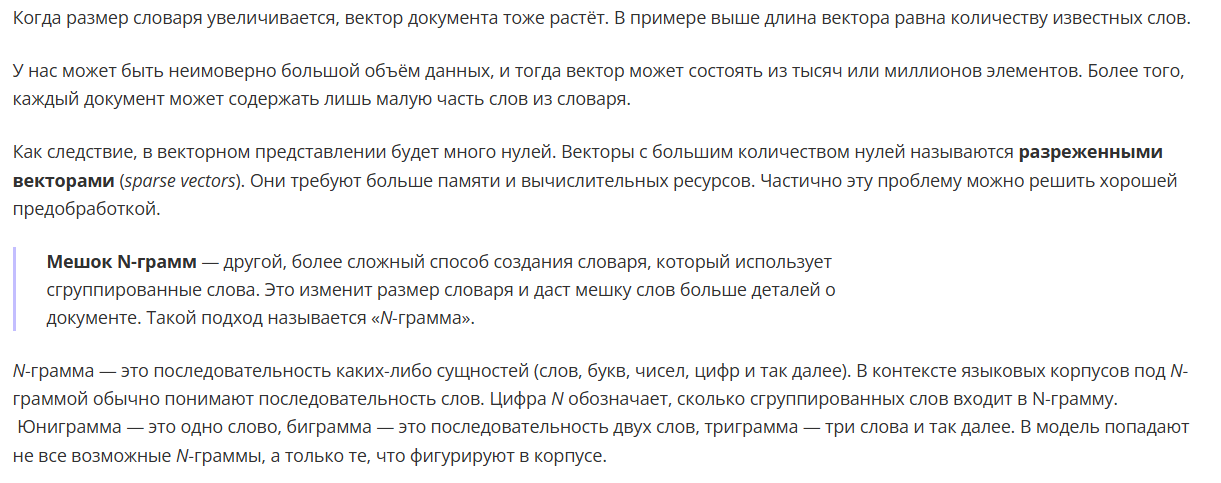

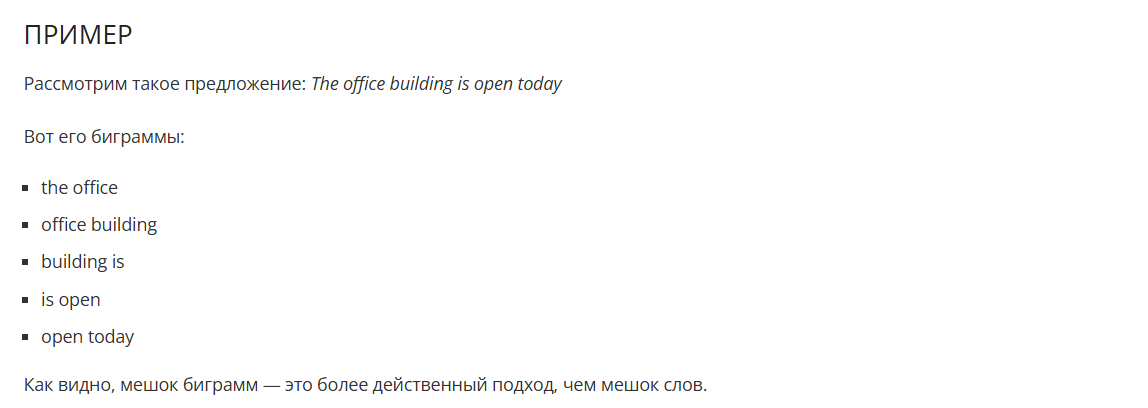

In [8]:
from nltk.util import ngrams
text = "I like this movie, it's funny. I hate this movie. This was awesome! I like it. Nice one. I love it."
tokenized = text.split()
bigrams = ngrams(tokenized, 2)

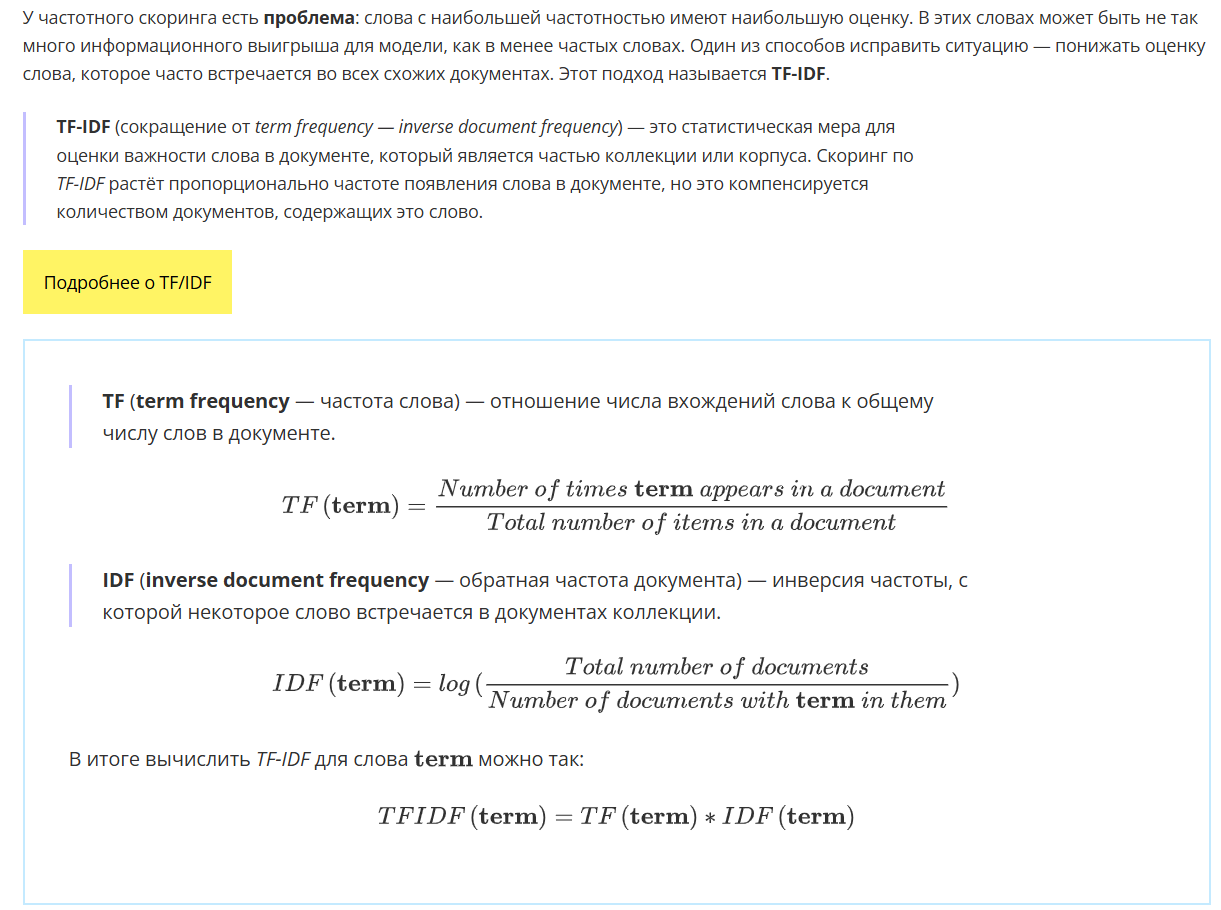

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
document = ["I like this movie, it's funny.", 'I hate this movie.', 'This was awesome! I like it.', 'Nice one. I love it.']
tfidf_vectorizer = TfidfVectorizer()
values = tfidf_vectorizer.fit_transform(document)
# Show the Model as a pandas DataFrame
feature_names = tfidf_vectorizer.get_feature_names_out()
pd.DataFrame(values.toarray(), columns = feature_names)

,awesome,funny,hate,it,like,love,movie,nice,one,this,was
0,0.000000,0.571848,0.000000,0.365003,0.450852,0.000000,0.450852,0.000000,0.000000,0.365003,0.000000
1,0.000000,0.000000,0.702035,0.000000,0.000000,0.000000,0.553492,0.000000,0.000000,0.448100,0.000000
2,0.539445,0.000000,0.000000,0.344321,0.425305,0.000000,0.000000,0.000000,0.000000,0.344321,0.539445
3,0.000000,0.000000,0.000000,0.345783,0.000000,0.541736,0.000000,0.541736,0.541736,0.000000,0.000000


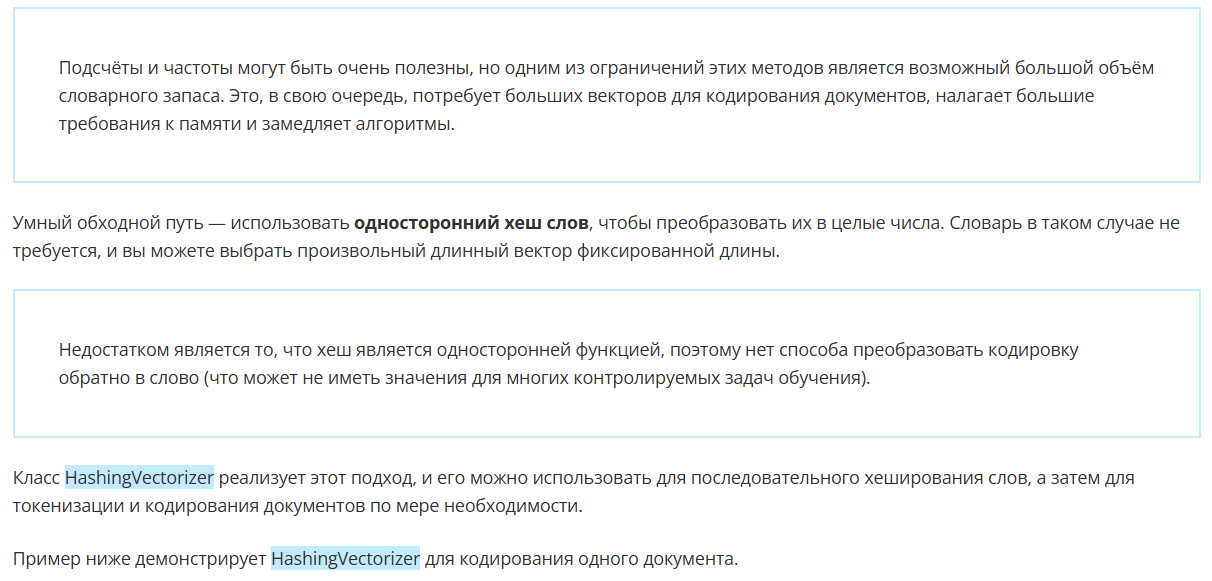

In [10]:
from sklearn.feature_extraction.text import HashingVectorizer
document = ["I like this movie, it's funny.", 'I hate this movie.', 'This was awesome! I like it.', 'Nice one. I love it.']
vectorizer = HashingVectorizer(n_features=2**4)
values = vectorizer.fit_transform(document)

# 6. Векторизация текстов: практика

Практическое задание этого юнита вы будете выполнять в Jupyter Notebook на датасете IMDB — наборе данных по классификации эмоциональной окраски отзывов. Тренировочная и тестовая части IMDB достаточно большие — каждая состоит из 25 000 примеров. Для доступа к нему мы используем библиотеку datasets — она содержит в себе много интересных текстовых датасетов.

Сохраните ноутбук на свой компьютер — задания на написание кода вы выполните в нём, а затем вставите его в форму ниже.


Место для вашего кода отмечено блоками # YOUR CODE STARTS ... #YOUR CODE ENDS — ваше решение должно быть строго между ними.

Чтобы решить задачу, вам будет необходимо смотреть в документацию соответствующего фреймворка. 

Ваша задача: предсказать по тексту отзыва к фильму, положительный ли он. Это довольно простая задача, хорошо решаемая даже линейными моделями. 

Линейная модель — очень сильный baseline; в некоторых задачах классификации и не нужно идти дальше линейной модели, поскольку она уже достаточно хороша. 

Шаги:

- Напишите линейную модель при помощи библиотеки sklearn. Для векторизации текста используйте TfidfVectorizer, а в качестве модели — LogisticRegression.
- Предскажите классы на тестовом сете и посчитайте accuracy.
- Использование модели LinearSVM обычно работает даже лучше, чем логистическая регрессия. Рекомендуем попробовать и сравнить.
- Используйте N-грамму в своём TF-IDF. Не забудьте указать параметр max_features (хорошее число 50 000) — при большом количестве фичей модель может начать переобучаться.

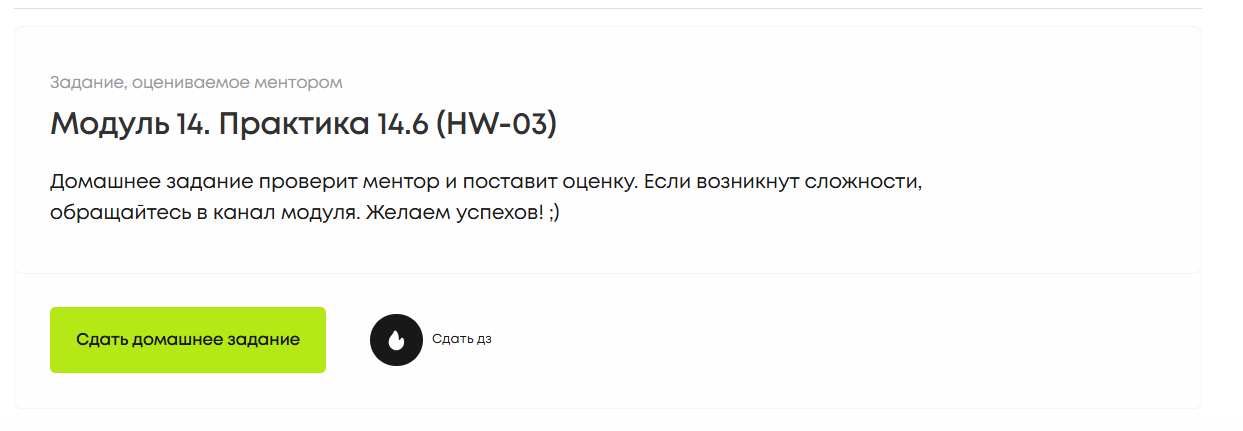